In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("insurance.csv")
df.head(10)
# df.tail(5)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87
1339,1340,30.0,female,47.4,101,No,0,Yes,southeast,63770.43


In [ ]:
df.info() # Show Data informations + Can see missing data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [ ]:
df.shape # Show matrix dimension

(1340, 10)

In [ ]:
pd.set_option("display.float_format", "{:.2f}".format) ## Round float with 2 digit after comma

In [12]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01


In [13]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [ ]:
df.duplicated().sum() # Check duplicated data

np.int64(0)

In [ ]:
df.isna().sum() # Check Empty data

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [ ]:
df.dropna(inplace = True) # Remove rows with empty data

In [ ]:
df.shape #1340 -> 1332

(1332, 10)

In [18]:
df.isna().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [ ]:
df.describe() # Statistics indicators : df.describe(include = "all") to see more

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


In [20]:
df.describe(include = "all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


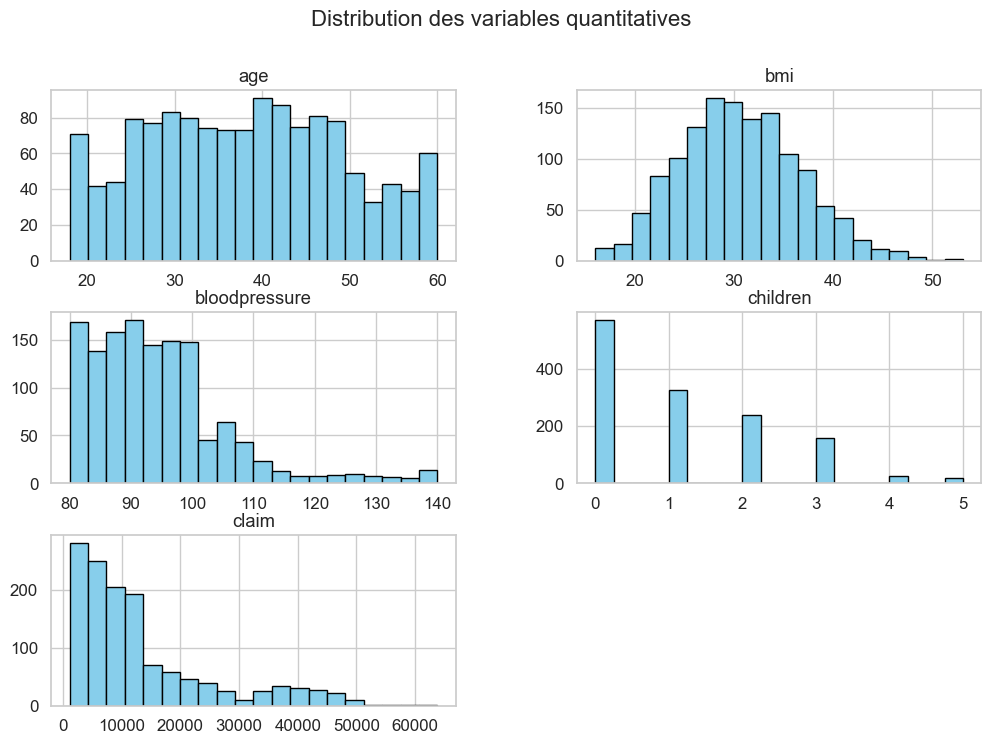

In [21]:
numeric_cols = ["age", "bmi", "bloodpressure", "children", "claim"]
df[numeric_cols].hist(bins=20, figsize=(12, 8), color = "skyblue", edgecolor = "black")
plt.suptitle("Distribution des variables quantitatives", fontsize=16)
plt.show()

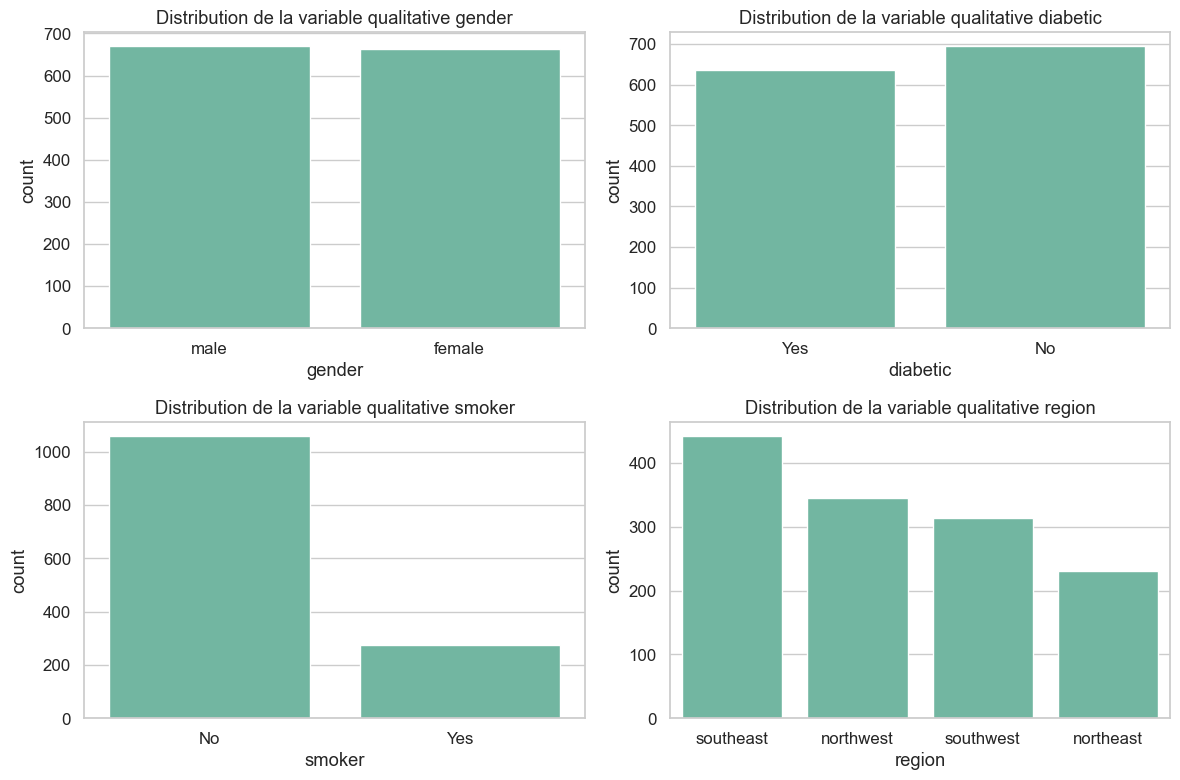

In [23]:
cat_cols = ["gender", "diabetic", "smoker", "region"]
plt.figure(figsize=(12, 8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data = df, x = col)
    plt.title(f"Distribution de la variable qualitative {col}")
plt.tight_layout()
plt.show()

In [ ]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2) # if someone is smoker, the insurance will be higher than a non smoker

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

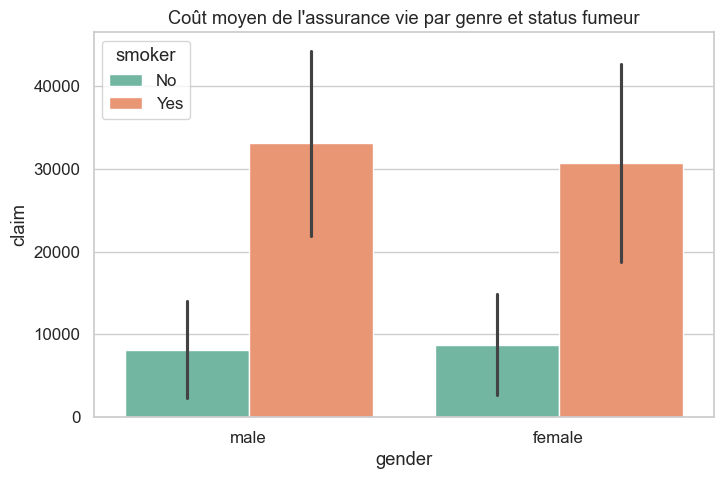

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "gender", y = "claim", hue = "smoker", estimator = "mean", errorbar = "sd")
plt.title("Coût moyen de l'assurance vie par genre et statut fumeur")
plt.show()

In [31]:
pivot_region_diabetic = df.groupby(["region", "diabetic"])["claim"].mean().unstack()
print(pivot_region_diabetic)

diabetic        No      Yes
region                     
northeast 16966.86 16818.30
northwest 11442.83 12224.96
southeast 13578.72 12574.09
southwest 13069.91 12313.74


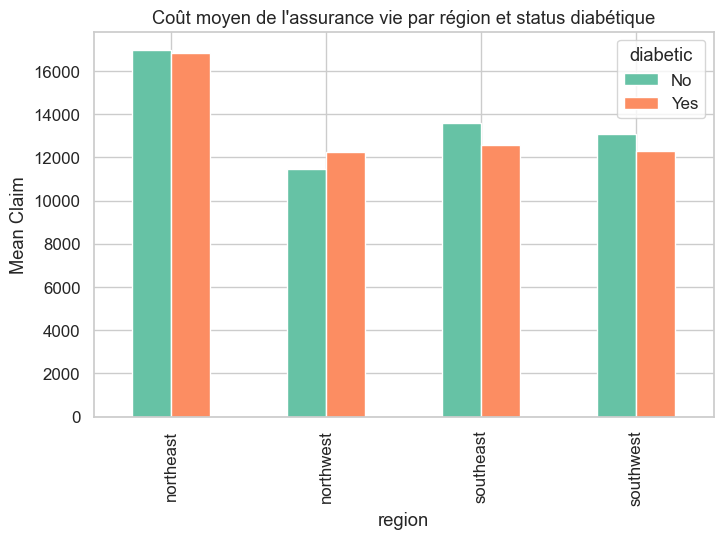

In [ ]:
pivot_region_diabetic.plot(kind = "bar", figsize=(8, 5))
plt.title("Coût moyen de l'assurance vie par région et statut diabétique")
plt.ylabel("Mean Claim")
plt.show()

In [34]:
pivot_table = pd.pivot_table(df, values = "claim", index = "region", columns = "smoker", aggfunc = "mean")
print(pivot_table)

smoker          No      Yes
region                     
northeast 11666.11 29673.54
northwest  8076.20 30192.00
southeast  7444.14 34845.00
southwest  8294.75 32269.06


In [35]:
pivot_table = pd.pivot_table(df, values = "claim", index = "children", columns = "diabetic", aggfunc = "mean")
print(pivot_table)

diabetic       No      Yes
children                  
0        12967.40 11985.29
1        12730.46 12732.06
2        15567.77 14579.36
3        13807.61 17091.26
4        14106.63 13573.35
5         8519.04  9205.59


                age   bmi  bloodpressure  children  claim
age            1.00 -0.04          -0.06     -0.03  -0.03
bmi           -0.04  1.00           0.14      0.01   0.20
bloodpressure -0.06  0.14           1.00     -0.03   0.53
children      -0.03  0.01          -0.03      1.00   0.06
claim         -0.03  0.20           0.53      0.06   1.00


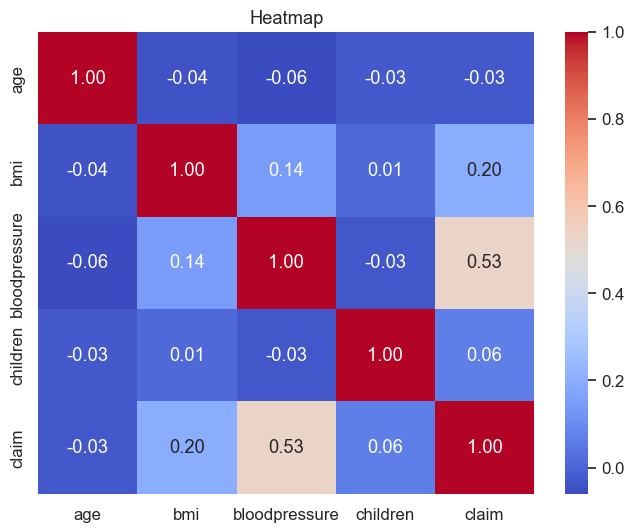

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Heatmap")
print(df[numeric_cols].corr())
plt.show()

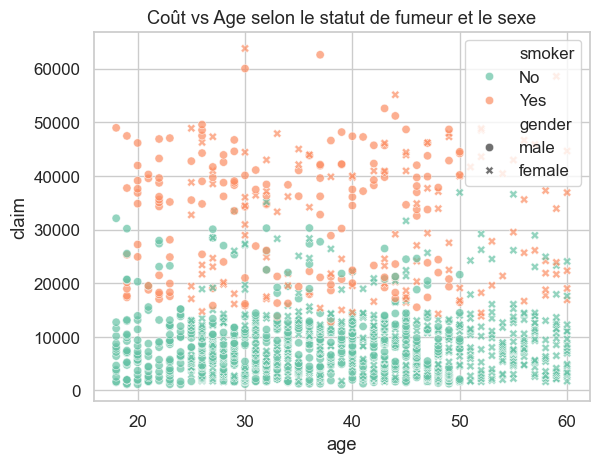

In [39]:
sns.scatterplot(data = df, x = "age", y = "claim", hue = "smoker", style = "gender", alpha = 0.7)
plt.title("Coût vs Age selon le statut de fumeur et le sexe")
plt.show()

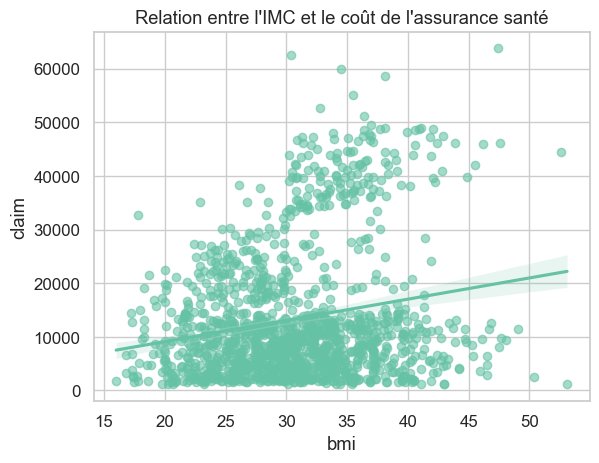

In [ ]:
sns.regplot(data = df, x = "bmi", y = "claim", scatter_kws={"alpha":0.6})
plt.title("Relation entre l'IMC et le coût de l'assurance santé")
plt.show() # When bmi increase, insurance payement increase too

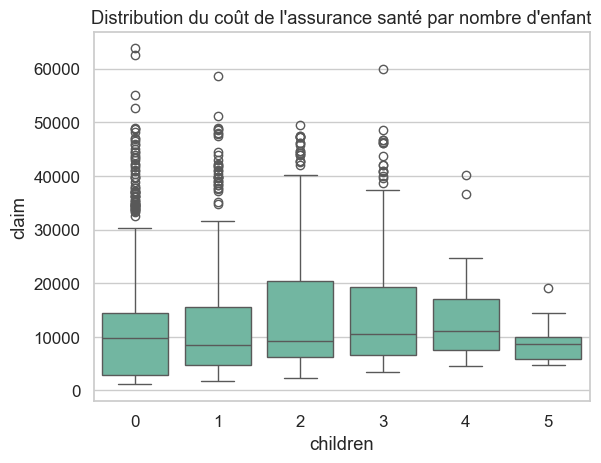

In [41]:
sns.boxplot(data = df, x = "children", y = "claim")
plt.title("Distribution du coût de l'assurance santé par nombre d'enfant")
plt.show()

In [45]:
df["age_group"] = pd.cut(df["age"], bins = [0, 18, 30, 45, 60, 100], labels = ["<18", "18-30", "30-45", "45-60", ">60"])
df.head()


,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,30-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30


In [46]:
df["age_group"].value_counts()

age_group
30-45    553
45-60    383
18-30    380
<18       16
>60        0
Name: count, dtype: int64

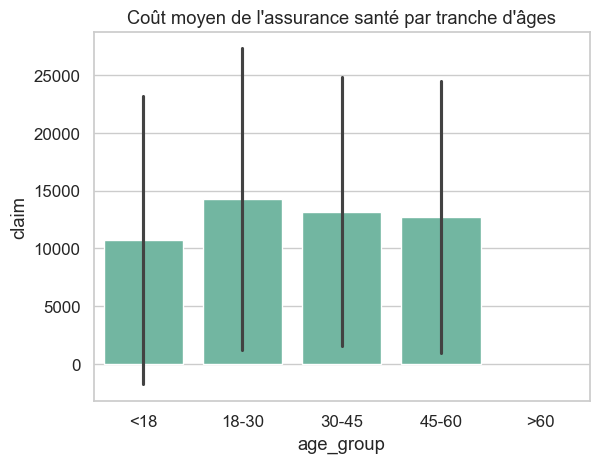

In [48]:
sns.barplot(data = df, x = "age_group", y = "claim", estimator = "mean", errorbar = "sd")
plt.title("Coût moyen de l'assurance santé par tranche d'âges")
plt.show()

In [49]:
df["bmi_category"] = pd.cut(df["bmi"], bins = [0, 18.5, 24.9, 29.9, 100], labels = ["Underweight", "Normal", "Overweight", "Obese"])

In [50]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

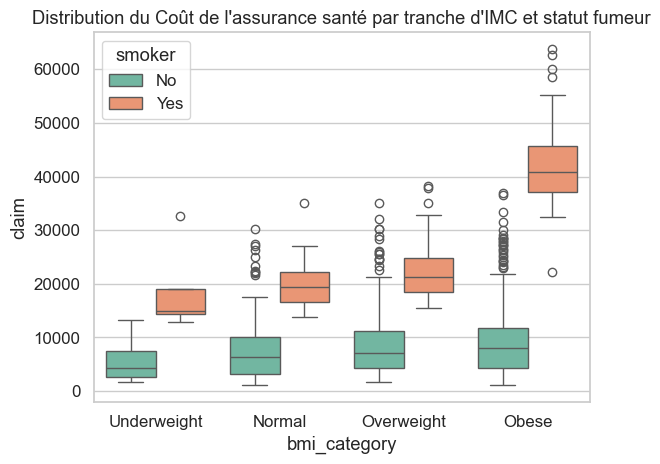

In [51]:
sns.boxplot(data = df, x = "bmi_category", y = "claim", hue = "smoker")
plt.title("Distribution du Coût de l'assurance santé par tranche d'IMC et statut fumeur")
plt.show()

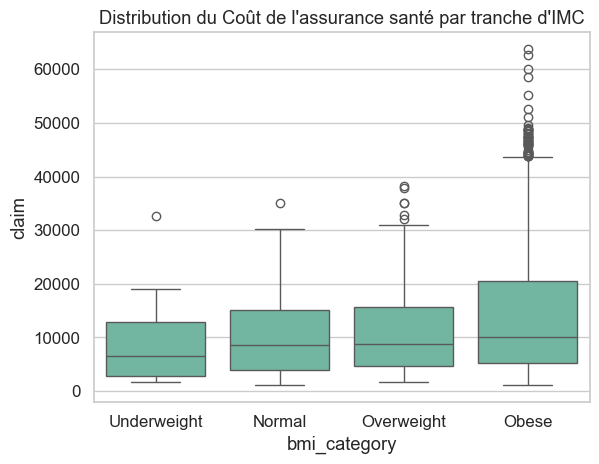

In [52]:
sns.boxplot(data = df, x = "bmi_category", y = "claim")
plt.title("Distribution du Coût de l'assurance santé par tranche d'IMC")
plt.show()

In [57]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x == "Yes").mean() * 100),
    mean_claim = ("claim", "mean")
).reset_index()

In [58]:
print(region_stats)

      region  smoker_rate  mean_claim
0  northeast        29.00    16889.04
1  northwest        16.81    11794.22
2  southeast        20.59    13085.50
3  southwest        18.47    12723.13


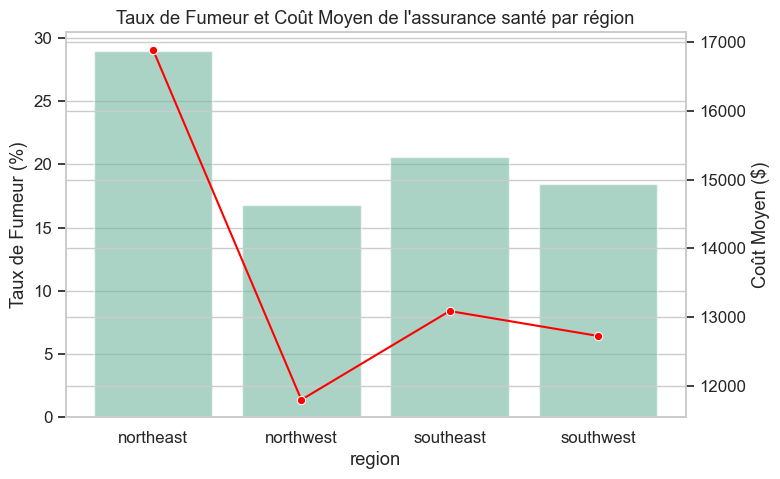

In [61]:
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(data = region_stats, x = "region", y = "smoker_rate", ax = ax1, alpha = 0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_stats, x = "region", y = "mean_claim", ax = ax2, color = "red", marker = "o")
ax1.set_ylabel("Taux de Fumeur (%)")
ax2.set_ylabel("Coût Moyen ($)")
plt.title("Taux de Fumeur et Coût Moyen de l'assurance santé par région")
plt.show()

In [101]:
## DATA PROCESSING FOR ML AND DATA SCIENCE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [102]:
print(df.columns)

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')


In [103]:
X = df[["age", "gender", "bmi", "bloodpressure", "diabetic", "children", "smoker"]]
Y = df["claim"]

In [104]:
cat_cols = ["gender", "diabetic", "smoker"]
label_encoders = {}

In [105]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f"label_encoder_{col}.pkl")

C:\Users\mattr\AppData\Local\Temp\ipykernel_9108\1530066519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\mattr\AppData\Local\Temp\ipykernel_9108\1530066519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\mattr\AppData\Local\Temp\ipykernel_9108\1530066519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [106]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [107]:
num_cols = ["age", "bmi", "bloodpressure", "children"]
scaler = StandardScaler()

In [108]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [109]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [110]:
print(X_train.shape, Y_train.shape)

(1065, 7) (1065,)


In [76]:
print(X_test.shape, Y_test.shape)

(267, 7) (267,)


In [83]:
#!pip install xgboost
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [84]:
def evaluate_model(model, X_train, X_test, Y_train, Y_test):
    Y_pred = model.predict(X_test)
    r2 = r2_score(Y_test, Y_pred)
    mae = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

In [85]:
results = {}

In [88]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
results["Linear Regression"] = evaluate_model(lr, X_train, X_test, Y_train, Y_test)
print("Linear Regression model trained")

best_poly_model = None
best_poly_score = -np.inf
for degree in [2, 3]:
    poly = PolynomialFeatures(degree = degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, Y_train)

    score = poly_lr.score(X_test_poly, Y_test)

    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model

results[f"Polynomial Regression (deg = {degree})"] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), Y_train, Y_test)

print("Polynomial Regression models are trained")

rf = RandomForestRegressor()
rf_params = {
    "n_estimators": [100, 200], 
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring = "r2", n_jobs = -1, verbose = 0)
rf_grid.fit(X_train, Y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, X_train, X_test, Y_train, Y_test)

print("Random Forest training is completed, best parameters", rf_grid.best_params_)

svr = SVR()
svr_params = {
    "kernel": ["rbf", "poly", "linear"],
    "C": [1, 10, 50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2, 3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring="r2", n_jobs = -1, verbose = 0)
svr_grid.fit(X_train, Y_train)

best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, X_train, X_test, Y_train, Y_test)
print("SVR training is completed, best parameters : ", svr_grid.best_estimator_)

xgb = XGBRegressor(objective = "reg:squarederror")

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring="r2", n_jobs = -1, verbose = 0)
xgb_grid.fit(X_train, Y_train)

best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, X_train, X_test, Y_train, Y_test)
print("XGBoost training is completed, best parameters : ", xgb_grid.best_estimator_)

Linear Regression model trained
Polynomial Regression models are trained
Random Forest training is completed, best parameters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
SVR training is completed, best parameters :  SVR(C=50, degree=2, epsilon=0.5, kernel='linear')
XGBoost training is completed, best parameters :  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constrai

In [89]:
print(results)

{'Linear Regression': {'R2': 0.7290788237715546, 'MAE': 4864.350539145719, 'RMSE': np.float64(6261.982406178664)}, 'Polynomial Regression (deg = 2)': {'R2': 0.793513823964666, 'MAE': 4269.6722638284145, 'RMSE': np.float64(5466.833633020746)}, 'Random Forest': {'R2': 0.8313186244652995, 'MAE': 3834.845988636358, 'RMSE': np.float64(4941.103303650584)}, 'SVR': {'R2': 0.49435737587915607, 'MAE': 5873.85503423507, 'RMSE': np.float64(8554.846179269465)}, 'XGBoost': {'R2': 0.8461056815104732, 'MAE': 3650.3393632227294, 'RMSE': np.float64(4719.561614234148)}}


In [90]:
results_df = pd.DataFrame(results).T.sort_values(by = "R2", ascending = False)
print(results_df)

                                  R2     MAE    RMSE
XGBoost                         0.85 3650.34 4719.56
Random Forest                   0.83 3834.85 4941.10
Polynomial Regression (deg = 2) 0.79 4269.67 5466.83
Linear Regression               0.73 4864.35 6261.98
SVR                             0.49 5873.86 8554.85


In [92]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [93]:
best_r2 = results_df["R2"].max()

In [94]:
print(best_r2)

0.8461056815104732


In [95]:
top_model = results_df[results_df["R2"] == best_r2]

In [96]:
print(top_model)

          R2     MAE    RMSE
XGBoost 0.85 3650.34 4719.56


In [97]:
best_model = models[top_model.index[0]]

In [98]:
print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [99]:
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [100]:
print(f"Best model selected : {top_model.index[0]}")

Best model selected : XGBoost
